# Notebook Experiment Testing

In [2]:
import pytweezer.phasemask as pm

In [3]:
from pytweezer.experiment import motmaster_client
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.analysis import analysis as an
from pytweezer import phasemask as pm
from pytweezer import communication as com
import numpy as np
import matplotlib.pyplot as plt

texp = an.TweezerExperimentAnalysis(day='30', month='03Mar', year='2026')
exp = motmaster_client.MotMasterClient()

---- 30/03Mar/202026 Tweezer Experiment Analysis Initialised ----


In [4]:
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=10.0,
                 slm_pitch_um=8,
                 slm_res=(1200,1920),
                 input_beam_waist_mm=9.6)

--- System Configuration ---
SLM Plane Width: 15.36 mm
SLM Plane Height: 9.60 mm
Focal Plane Resolution x (pixel size): 0.5547 um
Focal Plane Resolution y (pixel size): 0.8875 um
Focal Plane Width: 1065.00 um
Focal Plane Height: 1065.00 um
Fresnel Lens Focal Length: 600.00 mm
Blazed Grating Displacement (dx, dy): (63.0, 7.0) um


In [5]:
W = np.ones((8, 8))
spacing_um = 7

target1 = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
pm_slm1, terms1, _ = PM.superposition_optimization(target1, max_iter=500, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 8x8
Spacing: 7 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.81e-05 | Uniformity: 60.48% | Min/Max ratio: 0.171
Iteration 010 | Mean-Squared Error: 3.62e-07 | Uniformity: 96.15% | Min/Max ratio: 0.832
Iteration 020 | Mean-Squared Error: 8.36e-08 | Uniformity: 98.15% | Min/Max ratio: 0.916
Iteration 030 | Mean-Squared Error: 1.69e-08 | Uniformity: 99.17% | Min/Max ratio: 0.963
Iteration 040 | Mean-Squared Error: 5.06e-08 | Uniformity: 98.56% | Min/Max ratio: 0.935
Iteration 050 | Mean-Squared Error: 1.46e-08 | Uniformity: 99.23% | Min/Max ratio: 0.966
Iteration 060 | Mean-Squared Error: 3.00e-09 | Uniformity: 99.65% | Min/Max ratio: 0.985
Iteration 070 | Mean-Squared Error: 2.89e-09 | Uniformity: 99.66% | Min/Max ratio: 0.986
Iteration 080 | Mean-Squared Error: 1.20e-09 | Uniformity: 99.78% | Min/Max ratio: 0.989
Iteration 090 | Mean-Squared Error: 2.43e-10 | Uniformity: 99.90% | Min/Max ratio: 0.994
Iteration

In [174]:
SLM = com.SLMClient()
pm_init = PM.superimpose([pm_slm1, PM.fresnel, PM.blaze])
pm_init_uint8 = PM.transform_phase_8bit(pm_init).get()
SLM.update_mask(pm_init_uint8)

{'status': 'success', 'msg': 'Mask updated successfully.'}

In [13]:
exp.set_script("RbTweezerBasic2026")
exp.set_iterations(10)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True, 'command': 'set_run_until_stopped', 'value': False}

In [14]:
exp.start_experiment()

{'ok': True,
 'command': 'start_experiment',
 'script': 'RbTweezerBasic2026',
 'completed': True,
 'has_parameters': False}

---
# Background

In [16]:
exp.set_script("RbTweezerBasic2026_BackgroundSubtracted")
exp.set_iterations(100)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.start_experiment()

{'ok': True,
 'command': 'start_experiment',
 'script': 'RbTweezerBasic2026_BackgroundSubtracted',
 'completed': True,
 'has_parameters': False}

Images loaded from tweezer image directory.
Looking for trap sites...
8x8 array detected.


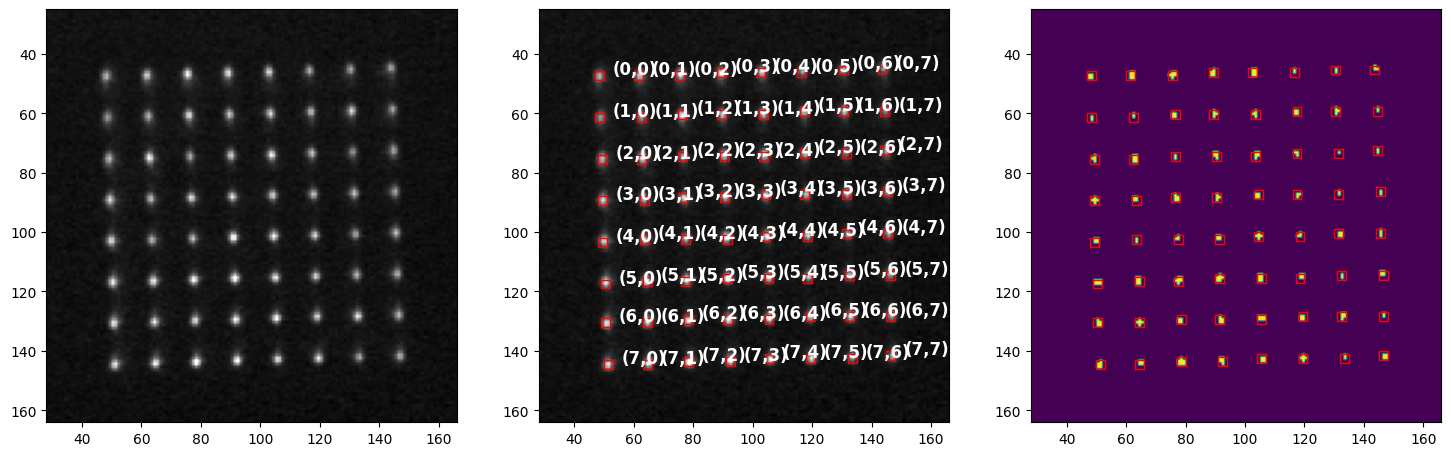

Trap (0, 0) Loading Probability : 48.0 %
Trap (0, 1) Loading Probability : 51.0 %
Trap (0, 2) Loading Probability : 56.99999999999999 %
Trap (0, 3) Loading Probability : 48.0 %
Trap (0, 4) Loading Probability : 48.0 %
Trap (0, 5) Loading Probability : 40.0 %
Trap (0, 6) Loading Probability : 34.0 %
Trap (0, 7) Loading Probability : 44.0 %
Trap (1, 0) Loading Probability : 45.0 %
Trap (1, 1) Loading Probability : 42.0 %
Trap (1, 2) Loading Probability : 44.0 %
Trap (1, 3) Loading Probability : 44.0 %
Trap (1, 4) Loading Probability : 49.0 %
Trap (1, 5) Loading Probability : 37.0 %
Trap (1, 6) Loading Probability : 50.0 %
Trap (1, 7) Loading Probability : 41.0 %
Trap (2, 0) Loading Probability : 52.0 %
Trap (2, 1) Loading Probability : 54.0 %
Trap (2, 2) Loading Probability : 40.0 %
Trap (2, 3) Loading Probability : 43.0 %
Trap (2, 4) Loading Probability : 53.0 %
Trap (2, 5) Loading Probability : 40.0 %
Trap (2, 6) Loading Probability : 32.0 %
Trap (2, 7) Loading Probability : 43.0 %
Tra

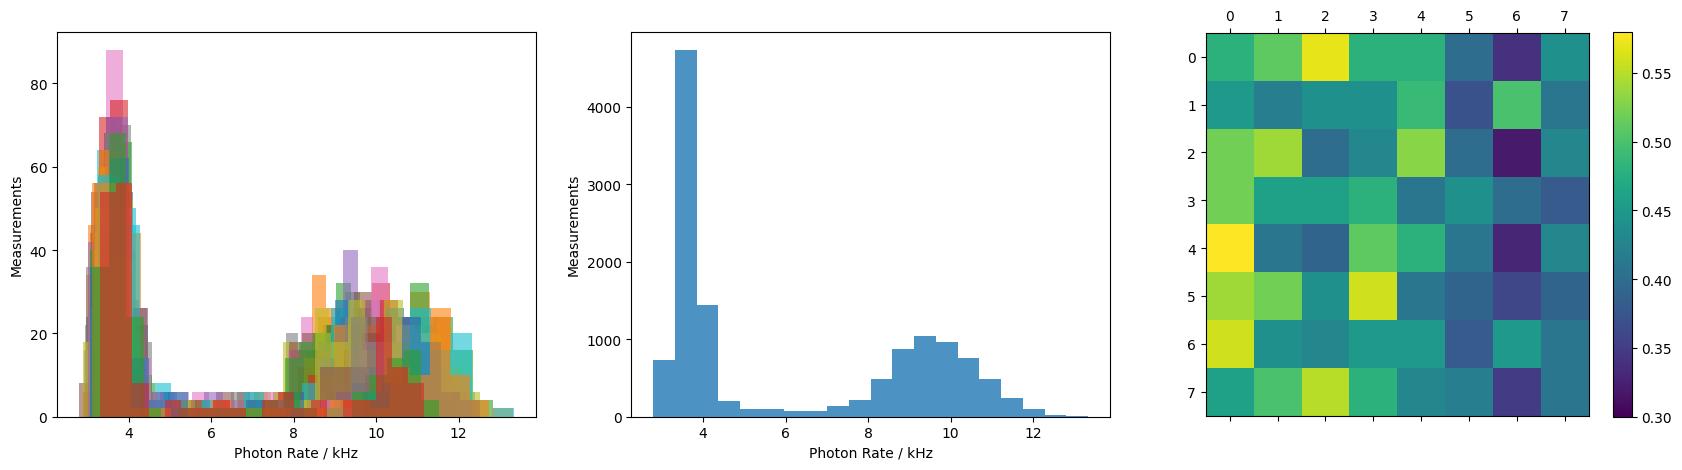

In [11]:
imgs = texp.get_tweezer_images()
imgs1 = imgs[::2]
imgs2 = imgs[1::2]

img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=False, vmaxfactor=0.6, show_grid=True)
grid_positions, detection_threshold = an.detect_trap_sites(img_average, [8,8], detection_step=200)
an.visualize_results(img_average, grid_positions, margin=20, window_size=3, threshold=detection_threshold)
photon_rates, loading_probabilities, threshold = texp.get_array_loading_probability(imgs1, grid_positions, [8,8], threshold=0, window_size=3, binning=20)
cvar = np.std(loading_probabilities) / loading_probabilities.mean()
print(f"Loading Threshold = {threshold:.6f} kHz")
print(f"Standard Deviation = {cvar*100} %")
print(f"Average Loading Prob = {loading_probabilities.mean()*100} %")

In [3]:
imgs = texp.get_tweezer_images()
imgs1 = imgs[::2]
imgs2 = imgs[1::2]

Images loaded from tweezer image directory.


Looking for trap sites...
8x8 array detected.


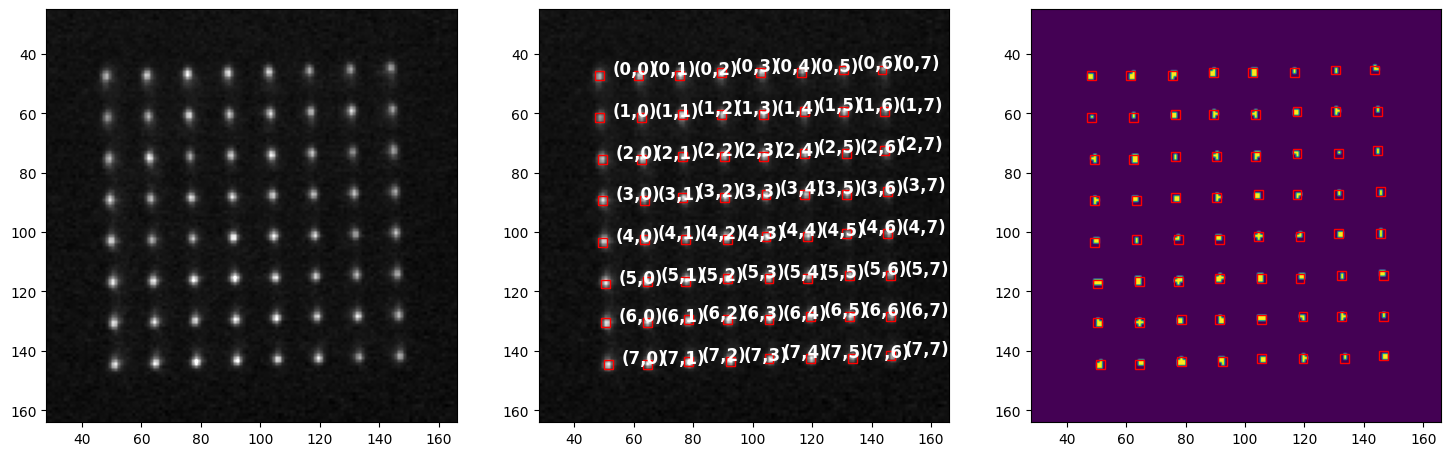

Trap (0, 0) Loading Probability : 48.0 %
Trap (0, 1) Loading Probability : 51.0 %
Trap (0, 2) Loading Probability : 56.99999999999999 %
Trap (0, 3) Loading Probability : 48.0 %
Trap (0, 4) Loading Probability : 48.0 %
Trap (0, 5) Loading Probability : 40.0 %
Trap (0, 6) Loading Probability : 34.0 %
Trap (0, 7) Loading Probability : 44.0 %
Trap (1, 0) Loading Probability : 45.0 %
Trap (1, 1) Loading Probability : 42.0 %
Trap (1, 2) Loading Probability : 44.0 %
Trap (1, 3) Loading Probability : 44.0 %
Trap (1, 4) Loading Probability : 49.0 %
Trap (1, 5) Loading Probability : 37.0 %
Trap (1, 6) Loading Probability : 50.0 %
Trap (1, 7) Loading Probability : 41.0 %
Trap (2, 0) Loading Probability : 52.0 %
Trap (2, 1) Loading Probability : 54.0 %
Trap (2, 2) Loading Probability : 40.0 %
Trap (2, 3) Loading Probability : 43.0 %
Trap (2, 4) Loading Probability : 53.0 %
Trap (2, 5) Loading Probability : 40.0 %
Trap (2, 6) Loading Probability : 32.0 %
Trap (2, 7) Loading Probability : 43.0 %
Tra

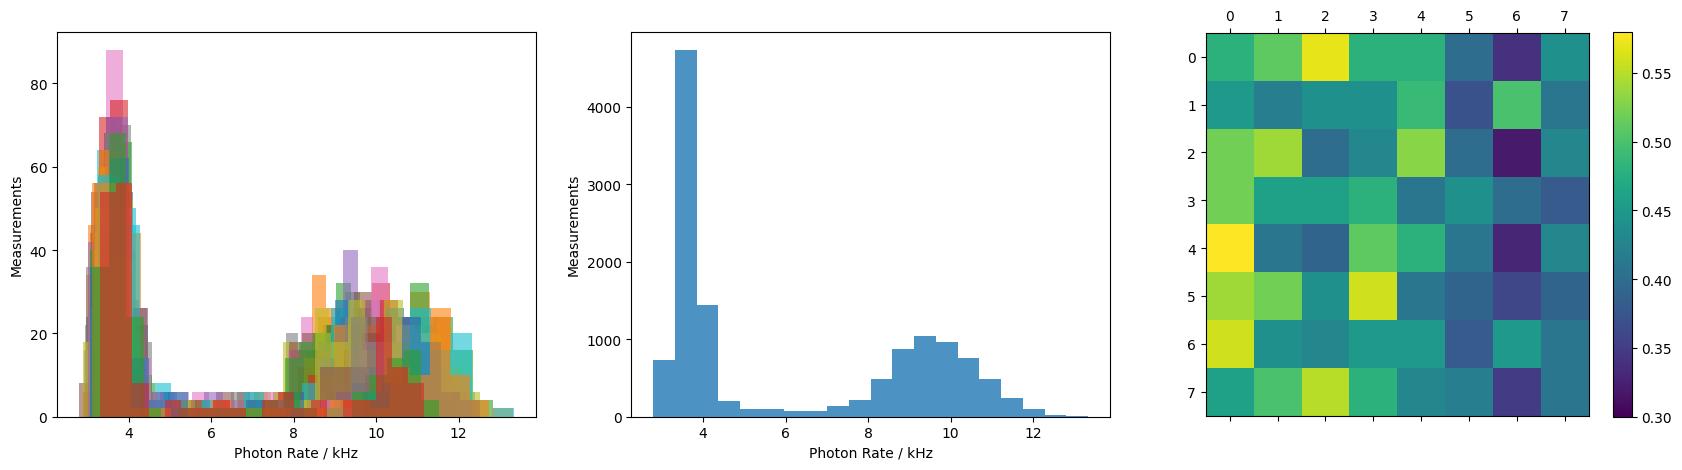

In [4]:
grid_positions, photon_rates, loading_probabilities, threshold = texp.array_baseline_measurement(imgs1, imgs2, grid_shape=[8,8], trap_size=3, detection_step=100)